In [1]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [2]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'z'}

In [3]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test5/rolling_z
['reference', 'info.json', 'target']


In [4]:
TARGET_VAR = 'pitch'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [20, 200], 'static': [200, 300]}
[200, 300]
[20, 200]


# IMPORTANDO DADOS

In [5]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df

,sample_time,wz,pitch,q0,q1,ay,wx,ax,q2,wy,time,la_pos_mon_d,az,roll,yaw,q3
0,5000000.0,-0.000072,0.007248,-0.6934,0.7202,9.779,-0.000131,0.1142,0.01248,-0.000272,2.384186e-07,0.6533,0.3700,-1.609,0.04163,-0.01705
1,605000000.0,0.000051,0.007244,-0.6934,0.7202,9.779,-0.000102,0.1144,0.01253,-0.000245,1.046014e-02,0.6197,0.3700,-1.609,0.04177,-0.01709
2,705000000.0,-0.000007,0.007248,-0.6934,0.7202,9.779,0.000237,0.1144,0.01254,-0.000218,1.129909e-01,0.6141,0.3700,-1.609,0.04179,-0.01710
3,805000000.0,0.000011,0.007244,-0.6934,0.7202,9.779,0.000151,0.1144,0.01255,-0.000370,2.098117e-01,0.6085,0.3701,-1.609,0.04182,-0.01711
4,905000000.0,-0.000008,0.007248,-0.6934,0.7202,9.779,0.000052,0.1142,0.01255,-0.000280,3.180597e-01,0.6029,0.3701,-1.609,0.04184,-0.01712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3049,405000000.0,-0.000243,0.028720,-0.6919,0.7197,9.779,-0.000324,0.1143,0.03047,-0.000234,3.048170e+02,-1.3000,0.3685,-1.608,0.11230,-0.04924
3050,505000000.0,-0.000147,0.028720,-0.6919,0.7197,9.778,0.000121,0.1139,0.03047,-0.000218,3.049235e+02,-1.3000,0.3682,-1.608,0.11230,-0.04924
3051,605000000.0,0.000091,0.028720,-0.6919,0.7197,9.779,-0.000098,0.1141,0.03048,-0.000143,3.050194e+02,-1.2990,0.3682,-1.608,0.11230,-0.04925
3052,705000000.0,-0.000030,0.028720,-0.6919,0.7197,9.779,0.000012,0.1135,0.03048,-0.000206,3.051234e+02,-1.2980,0.3679,-1.609,0.11230,-0.04926


- Convertendo pra radianos

In [6]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,sample_time,wz,pitch,q0,q1,ay,wx,ax,q2,wy,time,la_pos_mon_d,az,roll,yaw,q3
0,5000000.0,-0.004104,0.415280,-0.6934,0.7202,9.779,-0.007523,0.1142,0.01248,-0.015562,2.384186e-07,0.6533,0.3700,-92.188909,2.385223,-0.01705
1,605000000.0,0.002924,0.415051,-0.6934,0.7202,9.779,-0.005838,0.1144,0.01253,-0.014032,1.046014e-02,0.6197,0.3700,-92.188909,2.393245,-0.01709
2,705000000.0,-0.000379,0.415280,-0.6934,0.7202,9.779,0.013556,0.1144,0.01254,-0.012519,1.129909e-01,0.6141,0.3700,-92.188909,2.394391,-0.01710
3,805000000.0,0.000614,0.415051,-0.6934,0.7202,9.779,0.008657,0.1144,0.01255,-0.021182,2.098117e-01,0.6085,0.3701,-92.188909,2.396109,-0.01711
4,905000000.0,-0.000454,0.415280,-0.6934,0.7202,9.779,0.003004,0.1142,0.01255,-0.016037,3.180597e-01,0.6029,0.3701,-92.188909,2.397255,-0.01712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3049,405000000.0,-0.013946,1.645535,-0.6919,0.7197,9.779,-0.018552,0.1143,0.03047,-0.013396,3.048170e+02,-1.3000,0.3685,-92.131613,6.434316,-0.04924
3050,505000000.0,-0.008422,1.645535,-0.6919,0.7197,9.778,0.006933,0.1139,0.03047,-0.012496,3.049235e+02,-1.3000,0.3682,-92.131613,6.434316,-0.04924
3051,605000000.0,0.005229,1.645535,-0.6919,0.7197,9.779,-0.005587,0.1141,0.03048,-0.008170,3.050194e+02,-1.2990,0.3682,-92.131613,6.434316,-0.04925
3052,705000000.0,-0.001739,1.645535,-0.6919,0.7197,9.779,0.000715,0.1135,0.03048,-0.011791,3.051234e+02,-1.2980,0.3679,-92.188909,6.434316,-0.04926


In [7]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,sample_time,wz,pitch,q0,q1,ay,wx,ax,q2,wy,time,la_pos_mon_d,az,roll,yaw,q3


# VISUALIZAÇÃO DE VARIÁVEIS

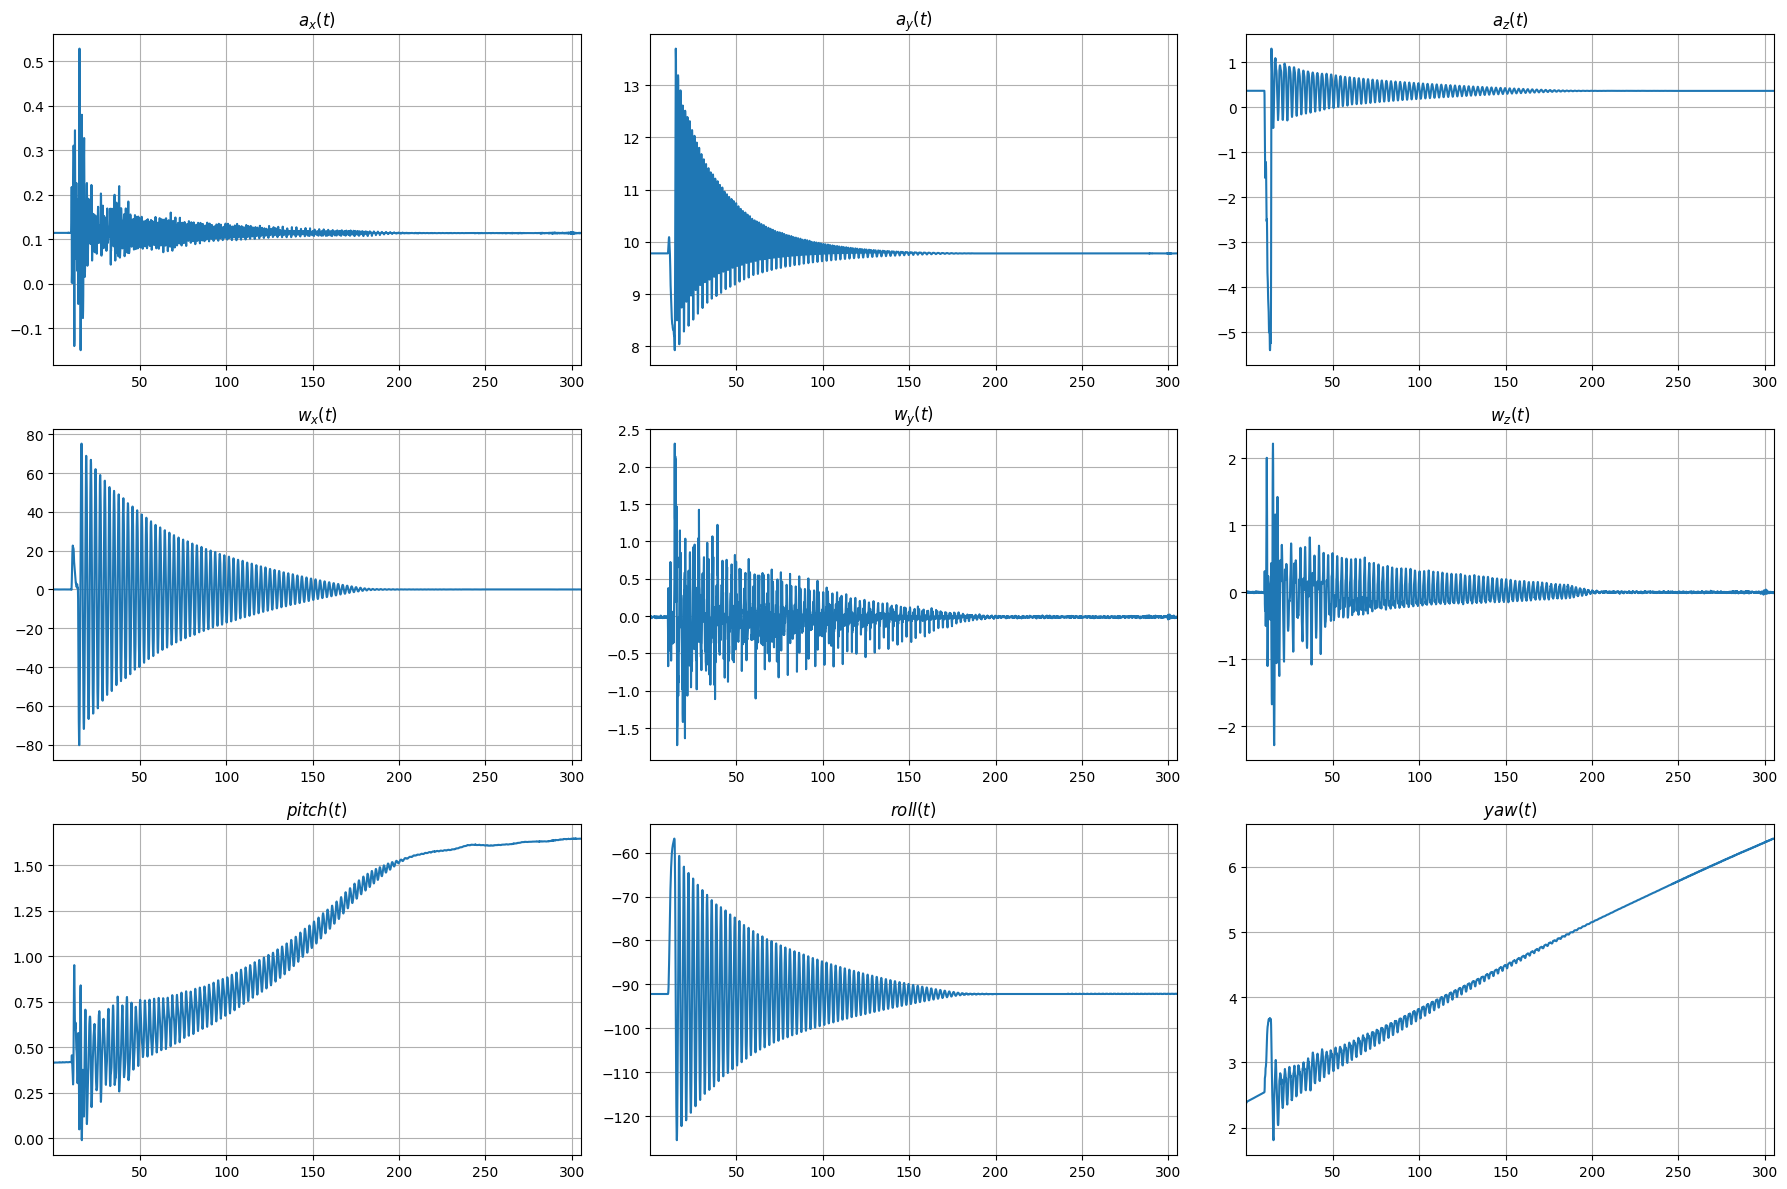

In [8]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

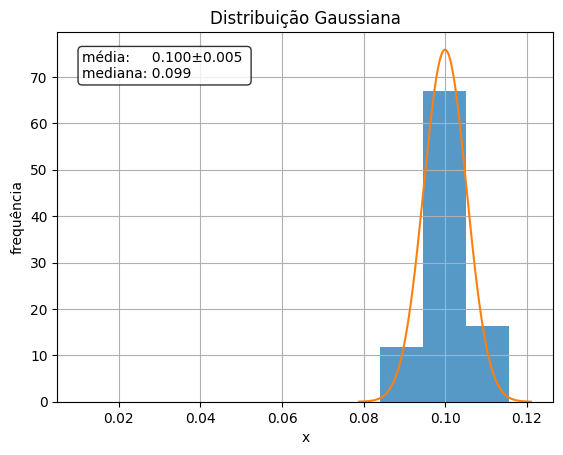

,time,sample_time,wz,pitch,q0,q1,ay,wx,ax,q2,wy,la_pos_mon_d,az,roll,yaw,q3
0,0.0,5000000.0,-0.004104,0.415280,-0.6934,0.7202,9.779,-0.007523,0.1142,0.01248,-0.015562,0.6533,0.3700,-92.188909,2.385223,-0.01705
1,0.1,605000000.0,0.002924,0.415051,-0.6934,0.7202,9.779,-0.005838,0.1144,0.01253,-0.014032,0.6197,0.3700,-92.188909,2.393245,-0.01709
2,0.2,705000000.0,-0.000379,0.415280,-0.6934,0.7202,9.779,0.013556,0.1144,0.01254,-0.012519,0.6141,0.3700,-92.188909,2.394391,-0.01710
3,0.3,805000000.0,0.000614,0.415051,-0.6934,0.7202,9.779,0.008657,0.1144,0.01255,-0.021182,0.6085,0.3701,-92.188909,2.396109,-0.01711
4,0.4,905000000.0,-0.000454,0.415280,-0.6934,0.7202,9.779,0.003004,0.1142,0.01255,-0.016037,0.6029,0.3701,-92.188909,2.397255,-0.01712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3049,304.9,405000000.0,-0.013946,1.645535,-0.6919,0.7197,9.779,-0.018552,0.1143,0.03047,-0.013396,-1.3000,0.3685,-92.131613,6.434316,-0.04924
3050,305.0,505000000.0,-0.008422,1.645535,-0.6919,0.7197,9.778,0.006933,0.1139,0.03047,-0.012496,-1.3000,0.3682,-92.131613,6.434316,-0.04924
3051,305.1,605000000.0,0.005229,1.645535,-0.6919,0.7197,9.779,-0.005587,0.1141,0.03048,-0.008170,-1.2990,0.3682,-92.131613,6.434316,-0.04925
3052,305.2,705000000.0,-0.001739,1.645535,-0.6919,0.7197,9.779,0.000715,0.1135,0.03048,-0.011791,-1.2980,0.3679,-92.188909,6.434316,-0.04926


In [9]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [10]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,sample_time,wz,pitch,q0,q1,ay,wx,ax,q2,wy,la_pos_mon_d,az,roll,yaw,q3,static
0,0.0,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.590,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120,False
1,0.1,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.540,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047,False
2,0.2,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.460,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959,False
3,0.3,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.170,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942,False
4,0.4,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.510,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,279.5,105000000.0,0.024133,1.645535,-0.6920,0.7197,9.783,-0.015711,0.11520,0.03009,-0.020449,-1.3240,0.3695,-92.131613,6.371291,-0.04888,True
2797,279.6,205000000.0,-0.022162,1.644962,-0.6920,0.7197,9.778,0.006503,0.11290,0.03010,-0.020529,-1.3240,0.3681,-92.131613,6.371291,-0.04888,True
2798,279.7,305000000.0,0.007128,1.645535,-0.6920,0.7197,9.783,-0.008749,0.11420,0.03010,-0.002209,-1.3230,0.3692,-92.131613,6.377020,-0.04889,True
2799,279.8,405000000.0,-0.020953,1.644962,-0.6920,0.7196,9.779,0.017951,0.11310,0.03012,-0.044284,-1.3230,0.3684,-92.131613,6.377020,-0.04890,True


# FILTRANDO POR VARIAVEL

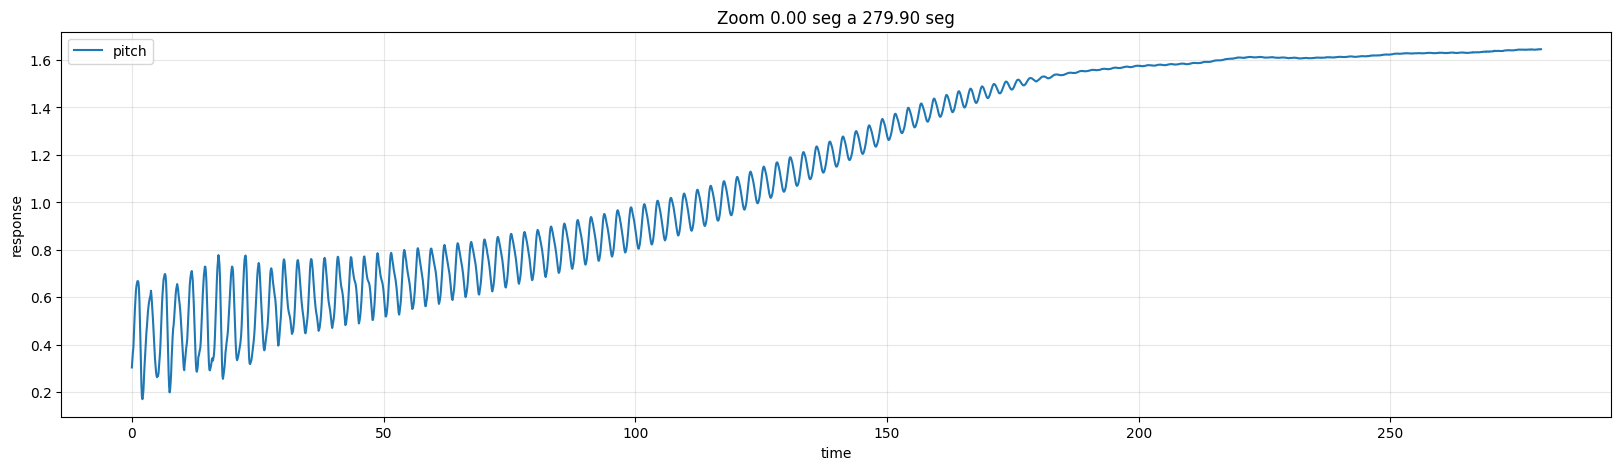

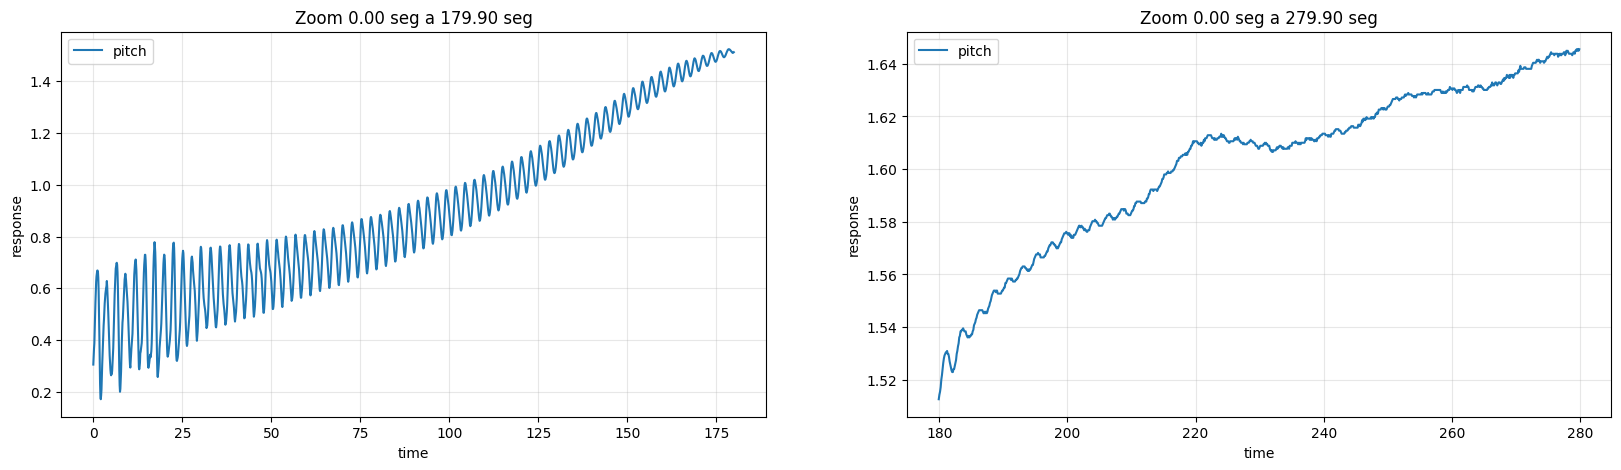

In [11]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [12]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,ref_sample_time,ref_wz,ref_pitch,ref_q0,ref_q1,ref_ay,ref_wx,ref_ax,ref_q2,ref_wy,ref_la_pos_mon_d,ref_az,ref_roll,ref_yaw,ref_q3,static
0,0.0,605000000.0,0.200478,0.304871,-0.8118,0.5835,9.590,-44.581846,0.06400,0.01196,0.471315,-0.5252,0.8262,-71.390541,2.771970,-0.02120,False
1,0.1,705000000.0,0.165413,0.337243,-0.7843,0.6199,10.540,-54.981030,0.09128,0.01243,0.546086,-0.4685,0.8149,-76.661753,2.723841,-0.02047,False
2,0.2,805000000.0,0.189592,0.366750,-0.7505,0.6604,11.460,-62.337808,0.12330,0.01297,0.585563,-0.4231,0.7793,-82.677810,2.667691,-0.01959,False
3,0.3,905000000.0,0.310085,0.387721,-0.7116,0.7021,12.170,-66.291217,0.19090,0.01440,-1.635795,-0.3990,0.7029,-89.209529,2.743322,-0.01942,False
4,0.4,5000000.0,0.653172,0.442381,-0.6696,0.7424,12.510,-66.806879,0.17590,0.01442,0.789536,-0.4016,0.5932,-95.913135,2.624720,-0.01821,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2796,279.5,105000000.0,0.024133,1.645535,-0.6920,0.7197,9.783,-0.015711,0.11520,0.03009,-0.020449,-1.3240,0.3695,-92.131613,6.371291,-0.04888,True
2797,279.6,205000000.0,-0.022162,1.644962,-0.6920,0.7197,9.778,0.006503,0.11290,0.03010,-0.020529,-1.3240,0.3681,-92.131613,6.371291,-0.04888,True
2798,279.7,305000000.0,0.007128,1.645535,-0.6920,0.7197,9.783,-0.008749,0.11420,0.03010,-0.002209,-1.3230,0.3692,-92.131613,6.377020,-0.04889,True
2799,279.8,405000000.0,-0.020953,1.644962,-0.6920,0.7196,9.779,0.017951,0.11310,0.03012,-0.044284,-1.3230,0.3684,-92.131613,6.377020,-0.04890,True


In [13]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)